In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
data=pd.read_csv("/content/vgsales (1).csv")
data

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [5]:
data.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [10]:
#Removing null
for col in data.columns:
  # Check if the column name 'col' is 'Year'
  if(col=="Year"):
    data[col]=data[col].fillna(0)
  else:
    data[col] =data[col].fillna(data[col].mode()[0])
data.isnull().sum()

,0
Rank,0
Name,0
Platform,0
Year,0
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [13]:
#check for duplicates
data.duplicated().sum()


np.int64(0)

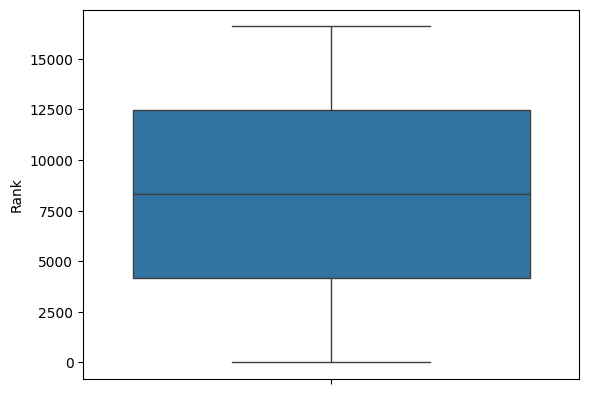

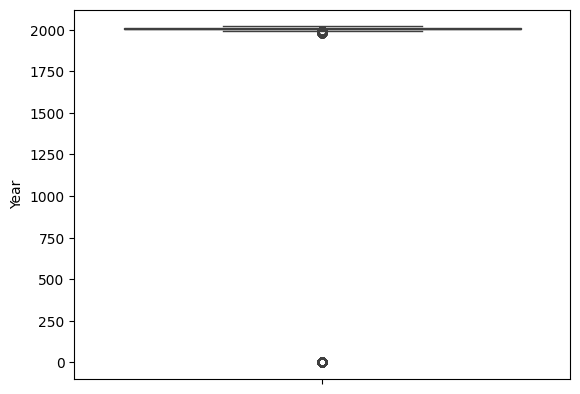

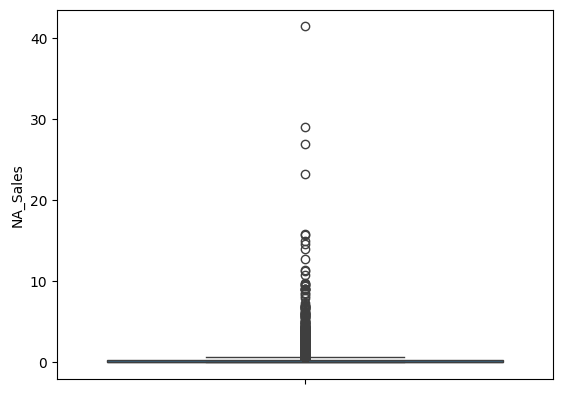

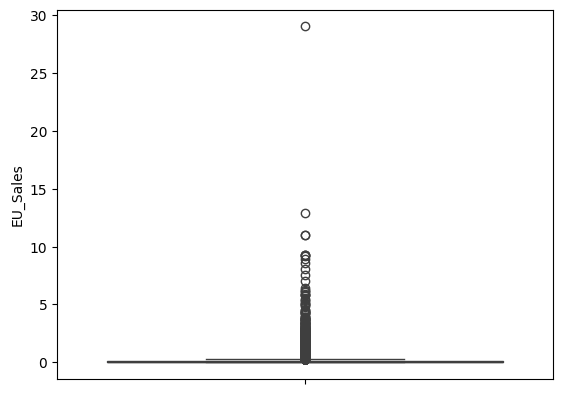

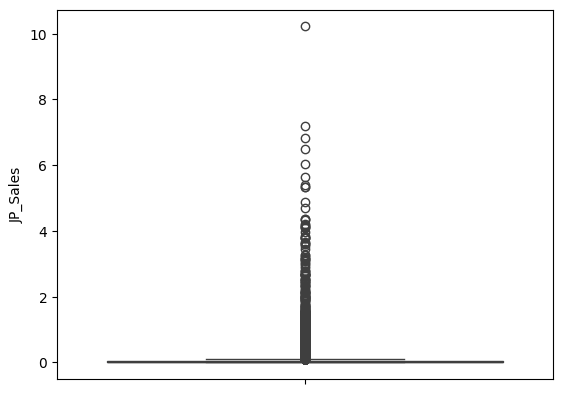

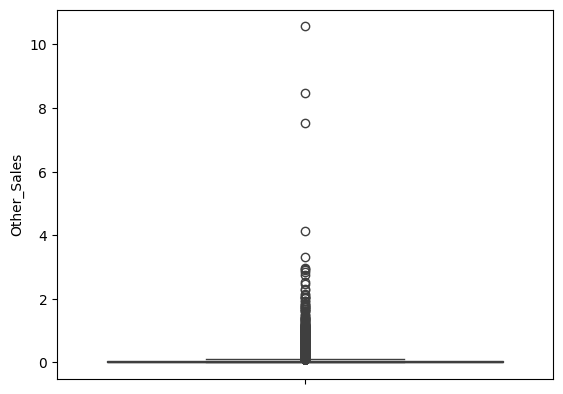

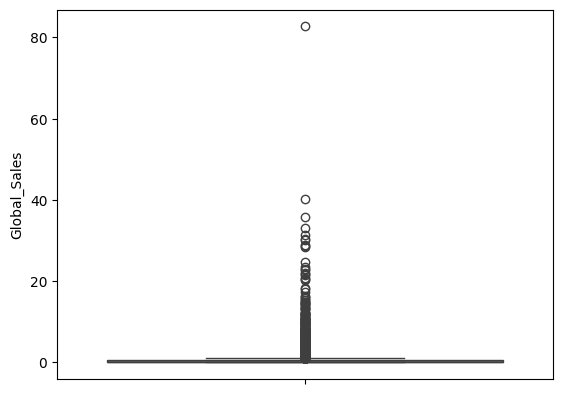

In [16]:
#findout th outliers
for col in data.columns:
  if(data[col].dtype !="object"):
    sns.boxplot(data[col])
    plt.show()


In [17]:
data.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

In [18]:
data.shape

(16598, 11)

In [23]:
#filter_out the outliers  rank has no outliers
#Actually more colums consists otrliers wiha re actually vbery away i am just calculating
list=[ 'NA_Sales','EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
for col in list:
  q1=data[col].quantile(0.25)
  q3=data[col].quantile(0.75)
  IQR=q3-q1
  LB=q1-1.5*IQR
  UB=q3+1.5*IQR
  data= data[(data[col]>=LB)& (data[col]<=UB)]
data.shape


(7446, 11)

In [26]:
#Label encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in data.columns:
  if data[col].dtype =="object":
    data[col]=le.fit_transform(data[col])
data

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
5820,5822,2264,4,2009.0,9,423,0.28,0.01,0.0,0.02,0.30
5822,5824,5398,5,2005.0,0,19,0.22,0.08,0.0,0.01,0.30
5823,5825,3419,4,2006.0,0,393,0.28,0.00,0.0,0.02,0.30
5824,5826,2982,23,2003.0,6,264,0.23,0.07,0.0,0.01,0.30
5825,5827,4405,5,2002.0,6,391,0.22,0.08,0.0,0.01,0.30
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,5639,5,2002.0,4,218,0.01,0.00,0.0,0.00,0.01
16594,16597,2932,6,2003.0,8,194,0.01,0.00,0.0,0.00,0.01
16595,16598,4179,12,2008.0,6,19,0.00,0.00,0.0,0.00,0.01
16596,16599,2548,4,2010.0,5,8,0.00,0.01,0.0,0.00,0.01
